In [54]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split, TensorDataset
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
import torch.nn.functional as F
import matplotlib.pyplot as plt
import my_bar
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from ipywidgets import interactive
import time
import importlib
importlib.reload(my_bar)

<module 'my_bar' from '/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/code/my_bar.py'>

In [55]:
x_numpy, y_numpy = my_bar.load_simulation_data()

In [57]:
if False:
    x_numpy = x_resampled
    y_numpy = y_resampled

In [58]:
x_normalized, x_means, x_stds = my_bar.normalize(x_numpy)
y_normalized, y_means, y_stds = my_bar.normalize(y_numpy)

x_denormalized = my_bar.denormalize(x_normalized, x_means, x_stds)
y_denormalized = my_bar.denormalize(y_normalized, y_means, y_stds)

In [59]:
dim0 = y_numpy[:, 0]
dim1 = y_numpy[:, 1]
dim0_min = np.min(dim0)
dim0_max = np.max(dim0)
dim1_min = np.min(dim1)
dim1_max = np.max(dim1)
dim0_lims = [dim0_min - 10, dim0_max + 10]
dim1_lims = [dim1_min - 10, dim1_max + 10]

for i in range(y_numpy.shape[1]):
    print(i)
    print(np.min(y_numpy[:, i]))
    print(np.max(y_numpy[:, i]))

0
13.84243
125.66696
1
-2.0155506
117.13913


In [60]:
differences = np.diff(y_numpy, axis=0)
norms = np.linalg.norm(differences, axis=1)
trajectory_length = np.sum(norms)
mean_norm = np.mean(norms)
median_norm = np.median(norms)
max_norm = np.max(norms)
std_norm = np.std(norms)
print(trajectory_length)

1988.6013


In [61]:
differences_resampled = np.diff(y_resampled, axis=0)
norms_resampled = np.linalg.norm(differences_resampled, axis=1)
trajectory_length_resampled = np.sum(norms_resampled)
mean_norm_resampled = np.mean(norms_resampled)
median_norm_resampled = np.median(norms_resampled)
max_norm_resampled = np.max(norms_resampled)
std_norm_resampled = np.std(norms_resampled)
print(mean_norm_resampled)

3.7498391597090683


Text(0.5, 1.0, 'robot tip trajectory')

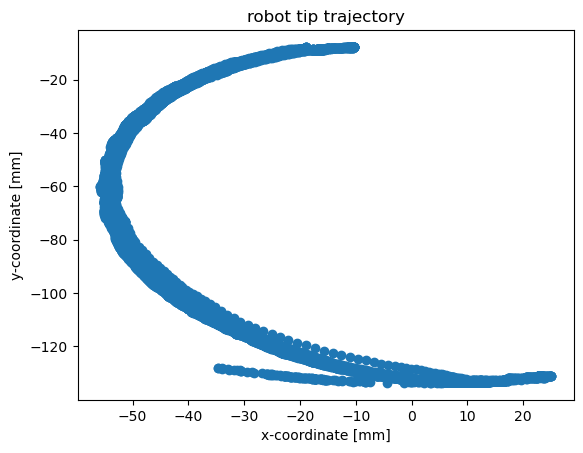

In [62]:
file_path = '~/Documents/university/MRIGI/group-project-70006/real-world-experiment-data/optitrack-3.csv'
df = pd.read_csv(file_path, header=None)
my_x = df.iloc[:, 1]
my_y = df.iloc[:, 2]
plt.figure()
plt.scatter(my_x, my_y)
plt.xlabel("x-coordinate [mm]")
plt.ylabel("y-coordinate [mm]")
plt.title("robot tip trajectory")

In [63]:
y = y_numpy
num_samples = y.shape[0]

# Function to plot a single point with a slider
def plot_point(sample_index):
    plt.figure(figsize=(5, 5))
    plt.scatter(y[sample_index, 0], y[sample_index, 1], color='blue')
    plt.xlim(dim0_lims)
    plt.ylim(dim1_lims)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.title(f'Sample {sample_index}')
    plt.show()

interactive_plot = interactive(plot_point, sample_index=(0, num_samples-1, 1))
interactive_plot

interactive(children=(IntSlider(value=354, description='sample_index', max=708), Output()), _dom_classes=('wid…

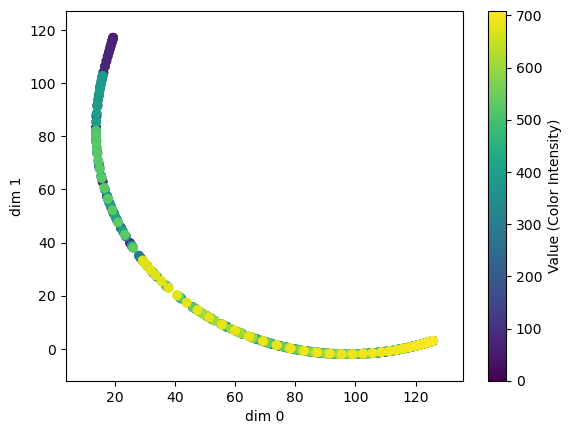

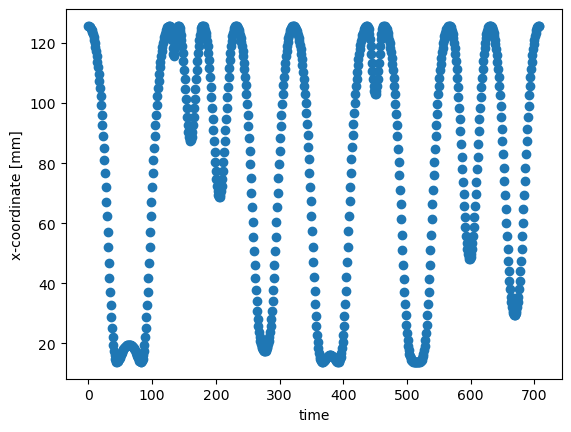

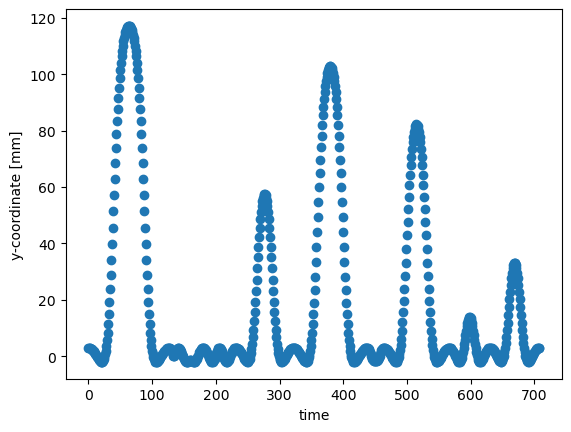

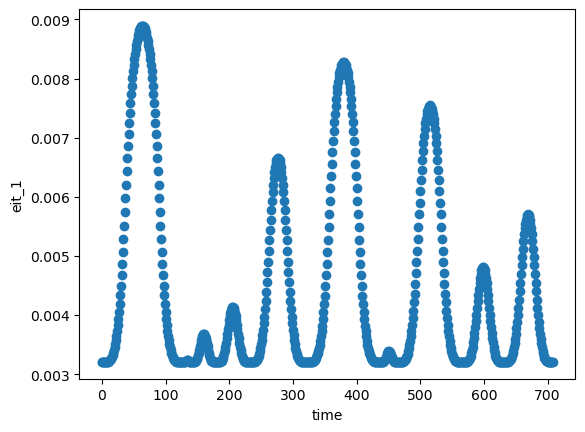

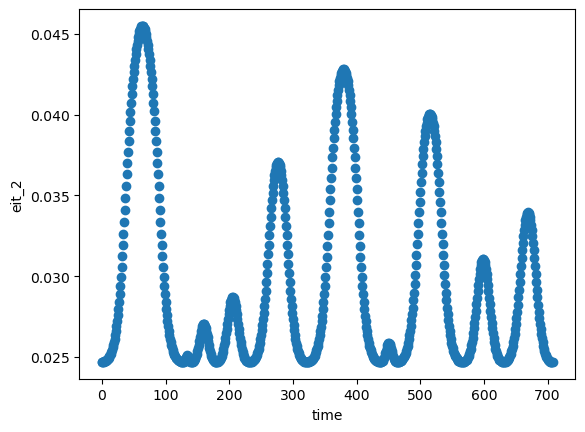

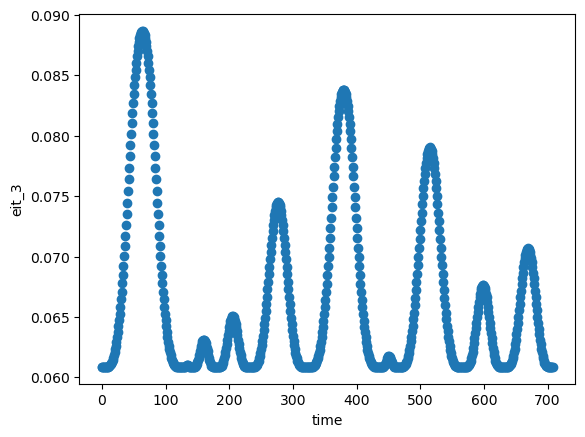

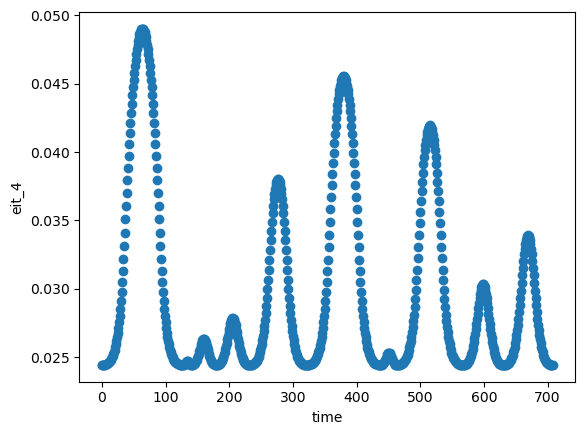

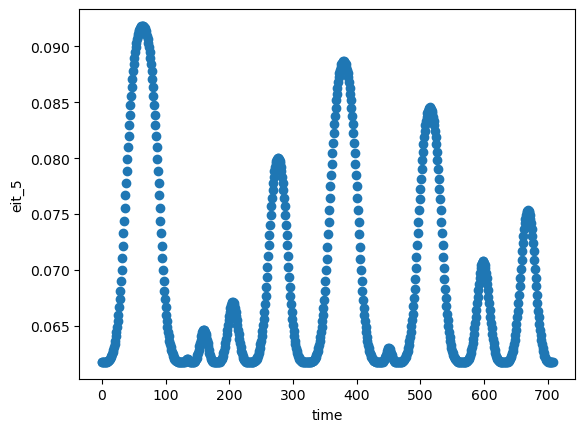

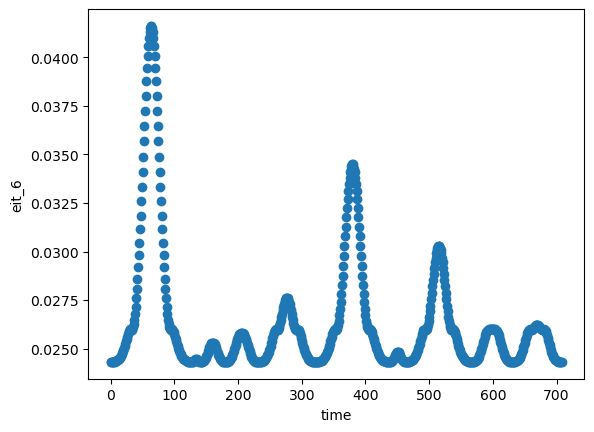

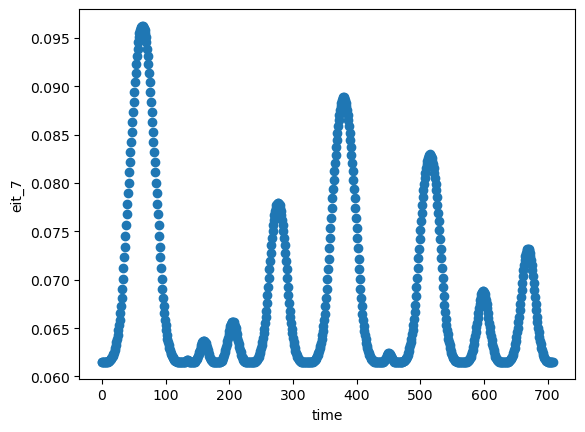

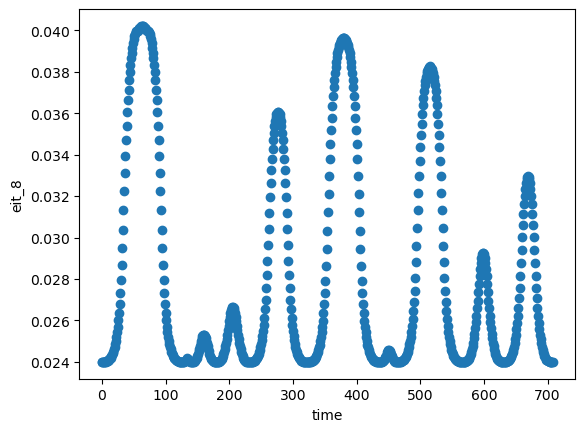

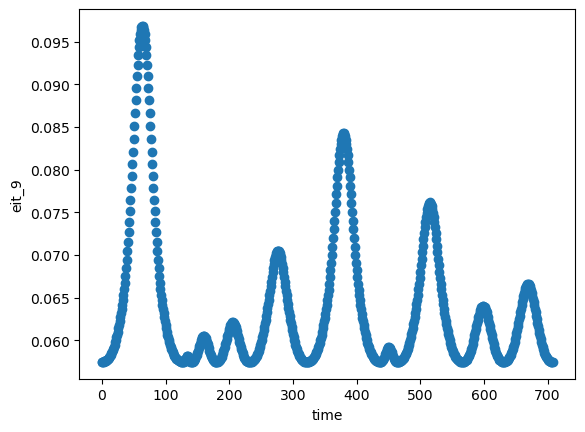

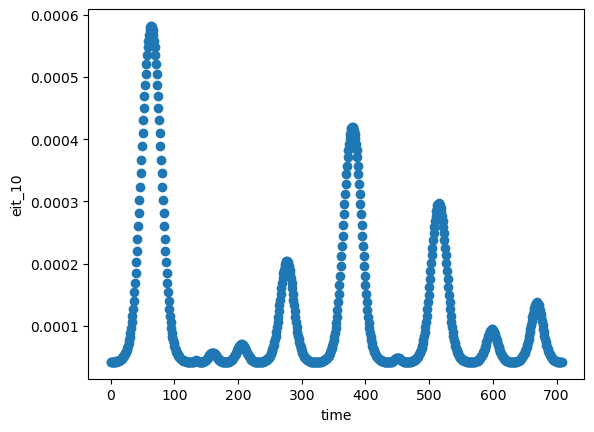

In [64]:
my_y = y_numpy[:, :]
x_coord = my_y[:, 0]
y_coord = my_y[:, 1]

plt.figure()
scatter = plt.scatter(x_coord, y_coord, c=list(range(my_y.shape[0])))
plt.xlabel("dim 0")
plt.ylabel("dim 1")
colorbar = plt.colorbar(scatter)
colorbar.set_label('Value (Color Intensity)')
plt.xlim(dim0_lims)
plt.ylim(dim1_lims)

for i in range(my_y.shape[1]):
    plt.figure()
    time = list(range(len(my_y[:, i])))
    vals = my_y[:, i]
    plt.scatter(time, vals)
    plt.xlabel('time')
    baz = "x" if i == 0 else "y"
    plt.ylabel(f"{baz}-coordinate [mm]")

for i in range(x_numpy.shape[1]):
    plt.figure()
    time = list(range(len(x_numpy[:, i])))
    vals = x_numpy[:, i]
    plt.scatter(time, vals)
    plt.xlabel('time')
    plt.ylabel(f'eit_{i + 1}')

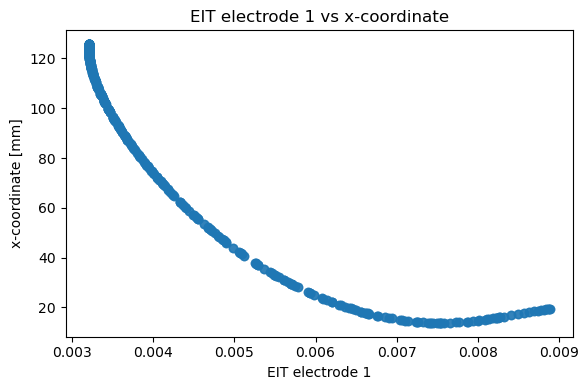

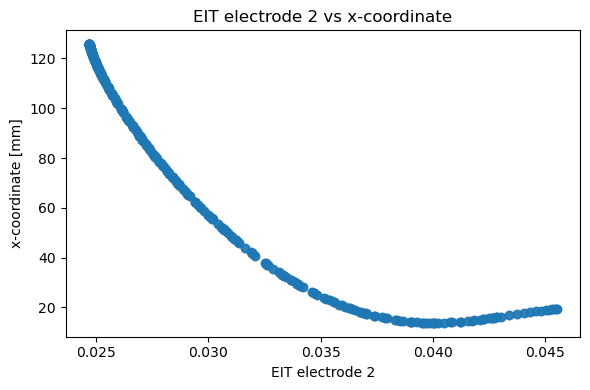

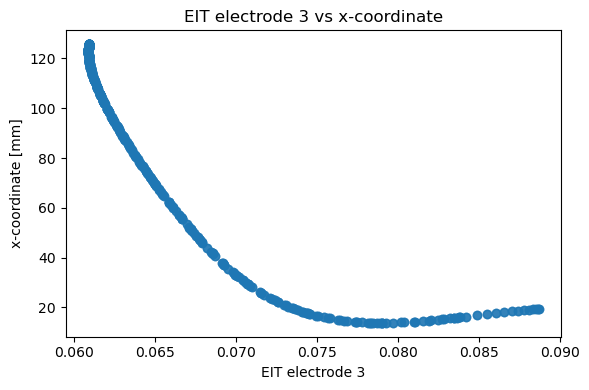

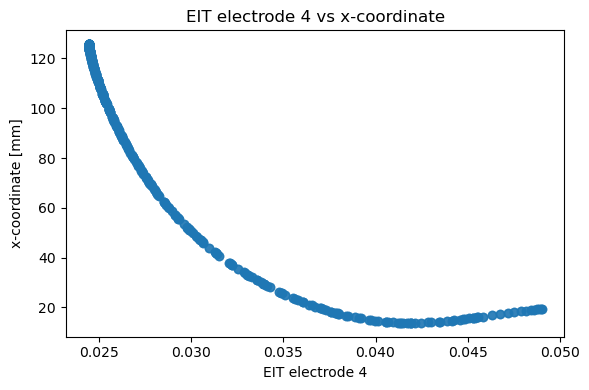

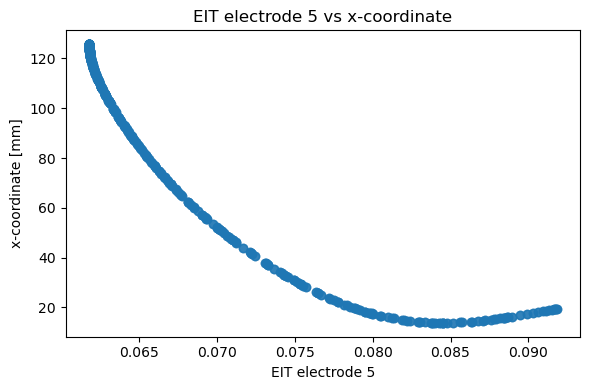

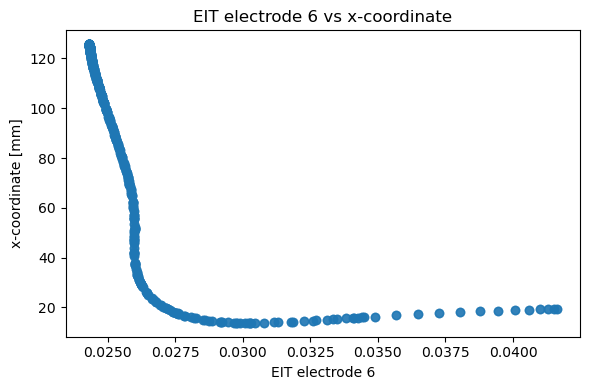

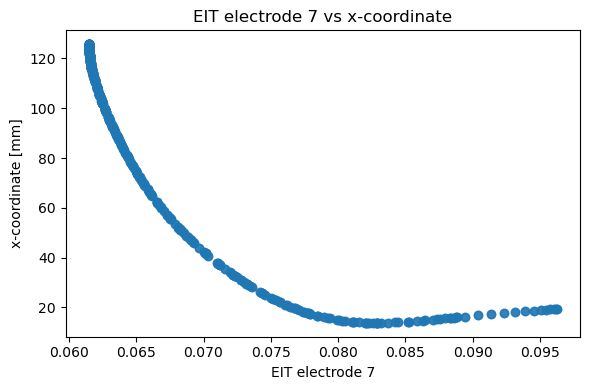

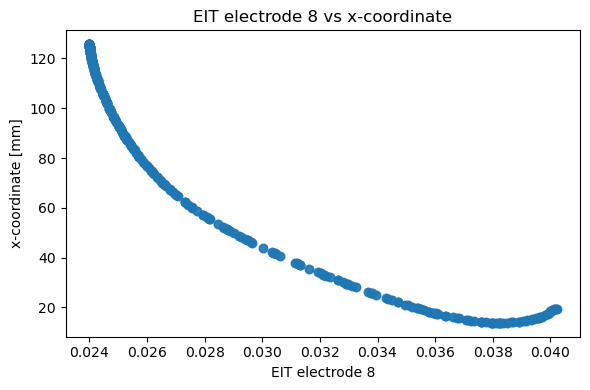

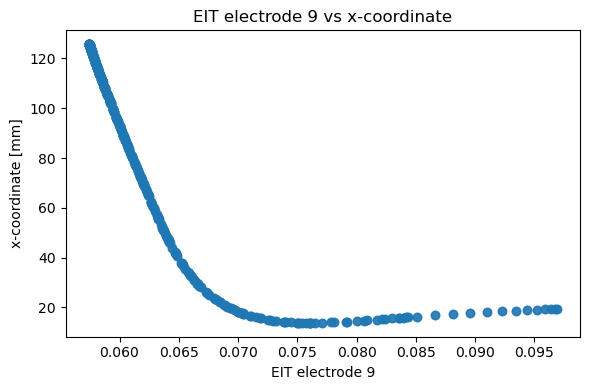

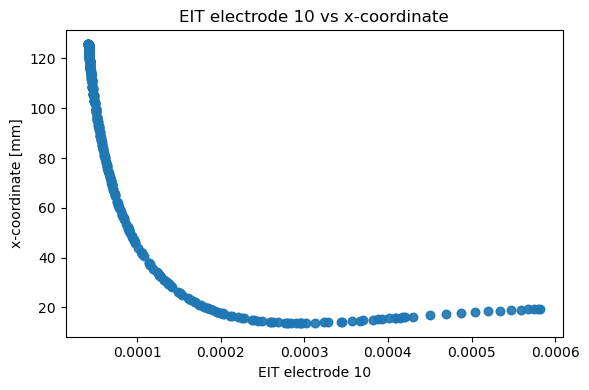

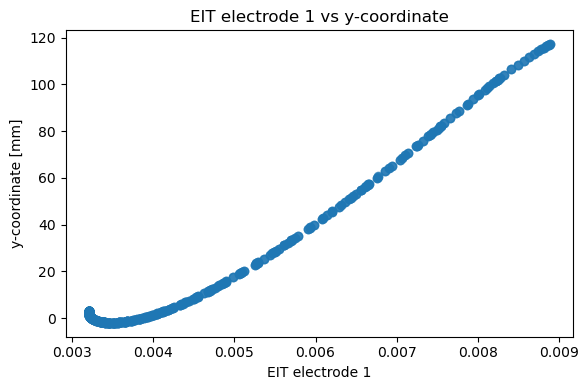

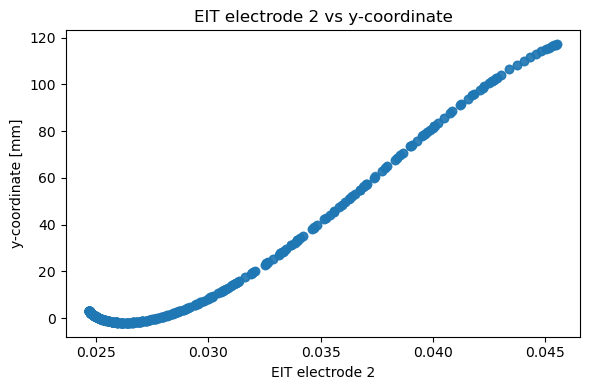

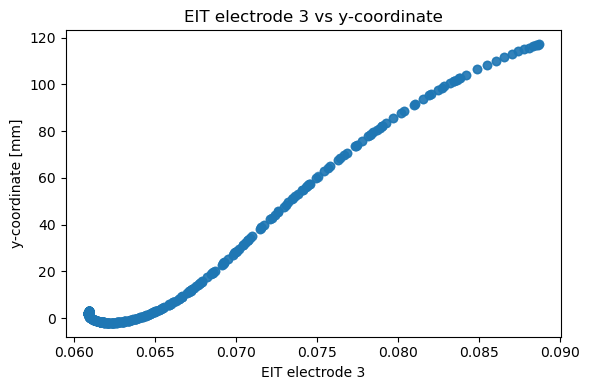

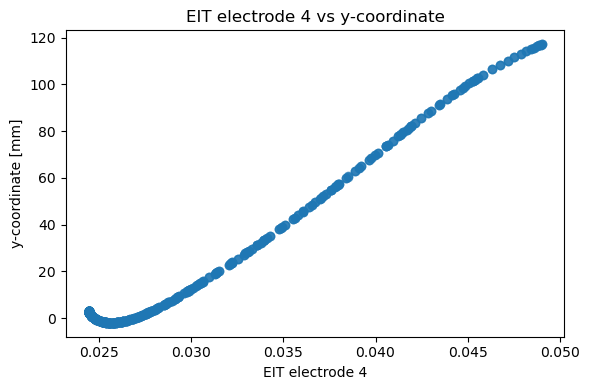

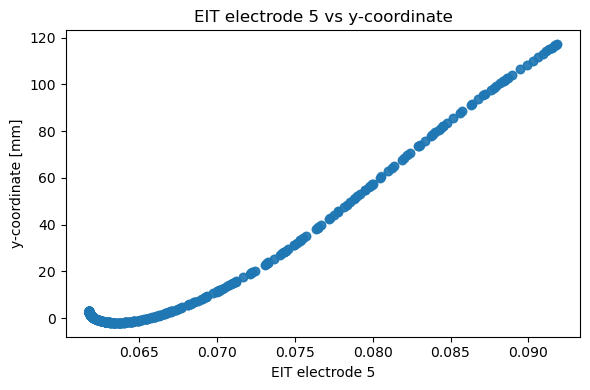

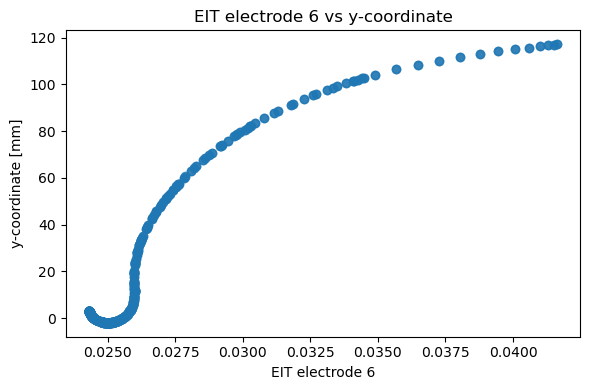

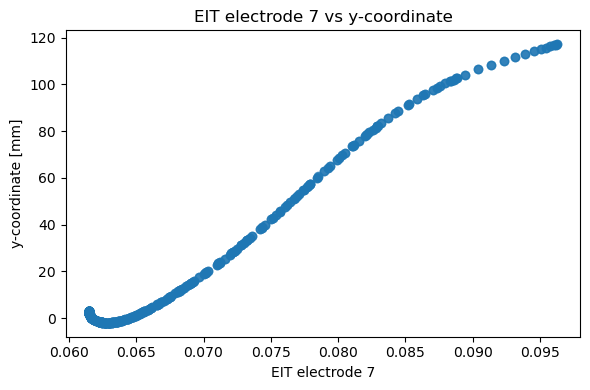

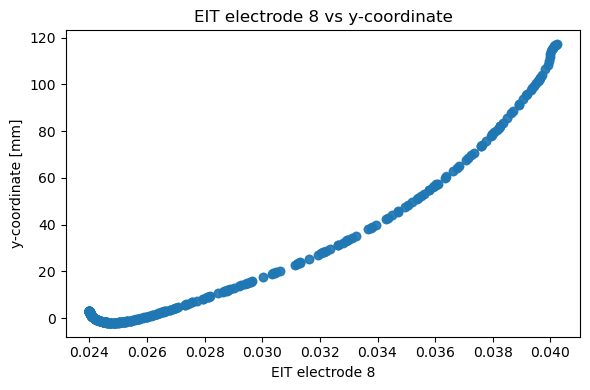

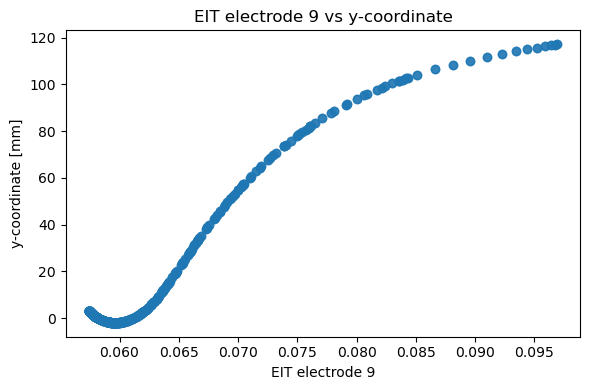

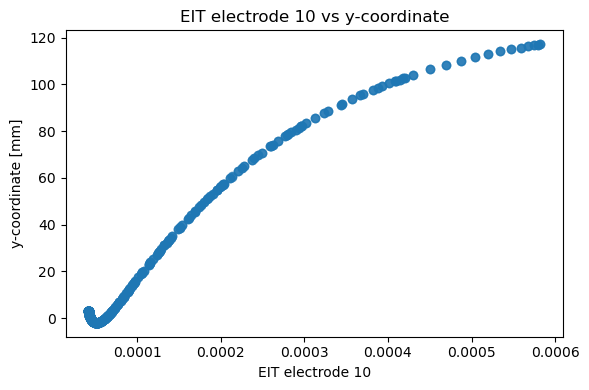

In [65]:
num_samples = x_numpy.shape[0]
num_input_dimensions = x_numpy.shape[1]
num_output_dimensions = y_numpy.shape[1]

# Iterate over all (input_dim, output_dim) pairs
for j in range(num_output_dimensions):
    for i in range(num_input_dimensions):
        # Create a new figure for each pair
        fig, ax = plt.subplots(figsize=(6, 4))
        
        # Scatter plot for the specific (input_dim, output_dim) pair
        ax.scatter(x_numpy[:, i], y_numpy[:, j], alpha=0.7)
        
        baz = "x" if j == 0 else "y"
        # Set the title and axis labels
        ax.set_title(f"EIT electrode {i+1} vs {baz}-coordinate")
        ax.set_xlabel(f"EIT electrode {i+1}")
        ax.set_ylabel(f"{baz}-coordinate [mm]")
        
        # Adjust layout and show the figure
        plt.tight_layout()
        plt.show()